# Certifying demographic parity, step by step

Five steps, start to finish:

1. **Define** the fairness criterion — demographic parity.
2. **Specify $\varepsilon$** — how equal is equal enough.
3. **Specify $\delta$** — how sure you need to be.
4. **Train.**
5. **Read the verdict** — a certified model, or *No Solution Found*.

Steps 2 and 3 are the two numbers you choose, and they do different jobs.
$\varepsilon$ is a property of the *definition*: shrink it and you demand a
smaller disparity, until no model in the class can deliver one.
$\delta$ is a property of the *evidence*: shrink it and you demand more
confidence from the same rows, until the data can no longer support the claim.

They fail in different ways, so the last two sections vary them one at a time.


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from fair_seldonian import demographic_parity
from fair_seldonian.algorithms import QSA
from fair_seldonian.config import SeldonianConfig
from fair_seldonian.data import data_split, get_data
from fair_seldonian.models import predict

warnings.filterwarnings("ignore")  # keep the demo output tidy

# Two groups with clearly different base rates: 35% of group 0 are positive
# against 65% of group 1. A disparity has to exist before it is worth certifying.
data = get_data(
    N=8000, features=5, t_ratio=0.5, tp0_ratio=0.35, tp1_ratio=0.65, random_seed=7
)
X_te, Y_te, T_te, X_tr, Y_tr, T_tr = data_split(
    frac=1.0, all_data=data, random_state=1, m_test=0.3
)

## 0. Coming from scikit-learn

If you already have `X`, `y` and a sensitive column as arrays, you are one call
away — but it is worth being precise about what this library does and does not
do.

**It does not wrap your estimator.** There is no way to hand `QSA` a fitted
`RandomForestClassifier`, a `Pipeline`, or a gradient-boosted model and get a
fair version back. `QSA` fits *its own* logistic regression,
$\sigma(X\theta + \theta_1)$, subject to the constraint. scikit-learn appears
inside the library only to supply a warm start.

**What it does** is answer this: given the arrays you would hand to
`LogisticRegression`, produce a logistic model that *provably* satisfies a
fairness constraint — or refuse. So the realistic comparison is your
unconstrained `LogisticRegression` against a certified-fair one on the same
data, which is what the rest of this notebook builds.

Start with the model you would have written anyway.


In [2]:
from sklearn.linear_model import LogisticRegression

# The model you would have written: no fairness constraint anywhere.
baseline = LogisticRegression(solver="lbfgs", max_iter=1000).fit(X_tr, Y_tr)
pred_sk = baseline.predict(X_te)

T_test = np.asarray(T_te)
rate_1 = float(pred_sk[T_test == 1].mean())
rate_0 = float(pred_sk[T_test == 0].mean())
acc_sk = float((pred_sk == np.asarray(Y_te)).mean())

print("sklearn LogisticRegression")
print(f"  accuracy                : {acc_sk:.3f}")
print(f"  positive rate, group 1  : {rate_1:.3f}")
print(f"  positive rate, group 0  : {rate_0:.3f}")
print(f"  demographic-parity gap  : {abs(rate_1 - rate_0):.3f}")

sklearn LogisticRegression
  accuracy                : 0.848
  positive rate, group 1  : 0.662
  positive rate, group 0  : 0.348
  demographic-parity gap  : 0.315


## 1. Define demographic parity

Demographic parity asks that both groups receive positive predictions at the
same rate. Within a group $P(\hat{Y}=1)$ is $\mathrm{TP} + \mathrm{FP}$, so the
criterion is

$$ g \;=\; \bigl|\,(\mathrm{TP}(1) + \mathrm{FP}(1)) - (\mathrm{TP}(0) + \mathrm{FP}(0))\,\bigr| \;-\; \varepsilon \;\le\; 0 $$

`demographic_parity(epsilon)` writes that in the postfix notation the library
expects, so there is no string to hand-assemble. The gap measured above is the
disparity this constraint will have to close.


In [3]:
print("the constraint string, for epsilon = 0.18:")
print(" ", demographic_parity(0.18))

the constraint string, for epsilon = 0.18:
  PR(1) PR(0) - abs 0.18 -


## 2 & 3. Specify $\varepsilon$ and $\delta$

$\varepsilon$ goes into the constraint; $\delta$ goes into the config. Together
they say: *the predicted-positive rates differ by at most $\varepsilon$, and I
want that to hold with probability at least $1 - \delta$.*


In [4]:
EPSILON = 0.18  # tolerated gap in predicted-positive rate
DELTA = 0.05  # guarantee holds with probability >= 1 - DELTA

config = SeldonianConfig(constraint=demographic_parity(EPSILON), delta=DELTA)
print(f"constraint : {config.constraint}")
print(f"delta      : {config.delta}  ->  holds w.p. >= {1 - config.delta:.2f}")

constraint : PR(1) PR(0) - abs 0.18 -
delta      : 0.05  ->  holds w.p. >= 0.95


## 4. Train

`QSA` splits the training data into a **candidate** set, used to search for a
model, and a **safety** set, used to certify it. Nothing the candidate search
sees is reused as evidence.


In [5]:
result = QSA(X_tr, Y_tr, T_tr, "opt", None, None, config)

## 5. Read the verdict

When the run certifies, the number to quote is `diagnostics.safety_upper_bound`
— the upper bound computed on the safety set, which is the evidence the
guarantee actually rests on. Re-evaluating the bound on some other split gives a
different number that carries no such claim.

When it does not certify, `diagnostics.failure_mode` says which of the two
refusals happened, and they call for opposite remedies:

- `candidate_infeasible` — no feasible model was found at all. More data will
  not help on its own; $\varepsilon$ is too tight for this model class.
- `safety_test_rejected` — a feasible model *was* found, but the safety set
  could not certify it. Here more data, or a tighter bound, is what helps.


In [6]:
if result.passed_safety:
    p = predict(result.theta, result.theta1, X_te).detach().numpy()
    pred = (p >= 0.5).astype(int)
    g1 = float(pred[T_test == 1].mean())
    g0 = float(pred[T_test == 0].mean())
    acc = float((pred == np.asarray(Y_te)).mean())
    print("CERTIFIED")
    print(f"  safety bound on g : {result.diagnostics.safety_upper_bound:+.4f}  (<= 0)")
    print()
    print(f"{'':<22}{'sklearn':>10}{'QSA':>10}")
    print(f"  {'parity gap':<20}{abs(rate_1 - rate_0):>10.3f}{abs(g1 - g0):>10.3f}")
    print(f"  {'accuracy':<20}{acc_sk:>10.3f}{acc:>10.3f}")
else:
    print("NO SOLUTION FOUND")
    print(f"  reason : {result.diagnostics.failure_mode}")

CERTIFIED
  safety bound on g : -0.0646  (<= 0)

                         sklearn       QSA
  parity gap               0.315     0.090
  accuracy                 0.848     0.765


## Varying $\varepsilon$: how equal is equal enough

$\delta$ fixed at 0.05. Tightening $\varepsilon$ eventually asks for a model
that does not exist, and the refusal is `candidate_infeasible`.


In [7]:
EPSILONS = [0.05, 0.10, 0.15, 0.18, 0.25]
eps_rows = []
for eps in EPSILONS:
    cfg = SeldonianConfig(constraint=demographic_parity(eps), delta=0.05)
    r = QSA(X_tr, Y_tr, T_tr, "opt", None, None, cfg)
    eps_rows.append((eps, r.passed_safety, r.diagnostics))
    verdict = (
        "certified"
        if r.passed_safety
        else f"no solution ({r.diagnostics.failure_mode})"
    )
    print(f"  epsilon = {eps:<5}  {verdict}")

  epsilon = 0.05   no solution (candidate_infeasible)


  epsilon = 0.1    certified


  epsilon = 0.15   certified


  epsilon = 0.18   certified


  epsilon = 0.25   certified


## Varying $\delta$: how sure you need to be

$\varepsilon$ fixed at 0.18. Here the disparity is *achievable* — what runs out
is **evidence**. Demanding more confidence widens every interval, and the
certified bounds below creep toward zero until they can no longer clear it.

Worth noting what the refusals report. They come back `candidate_infeasible`,
the same mode as tightening $\varepsilon$ — because the wider intervals make
even the candidate search infeasible, before the safety test gets a say. So
`failure_mode` tells you *where* the run stopped, not which knob caused it. The
two knobs differ in the remedy they call for, not always in the mode they
surface.

Note too that the certified bounds are not one model measured more cautiously:
candidate selection optimises against a $\delta$-dependent prediction of the
safety test, so each row is a slightly different model.


In [8]:
DELTAS = [0.25, 0.10, 0.05, 0.01, 0.001]
delta_rows = []
for dlt in DELTAS:
    cfg = SeldonianConfig(constraint=demographic_parity(0.18), delta=dlt)
    r = QSA(X_tr, Y_tr, T_tr, "opt", None, None, cfg)
    delta_rows.append((dlt, r.passed_safety, r.diagnostics))
    if r.passed_safety:
        verdict = f"certified   (safety bound {r.diagnostics.safety_upper_bound:+.4f})"
    else:
        verdict = f"no solution ({r.diagnostics.failure_mode})"
    print(f"  delta = {dlt:<6} {verdict}")

  delta = 0.25   certified   (safety bound -0.1023)


  delta = 0.1    certified   (safety bound -0.0979)
  delta = 0.05   certified   (safety bound -0.0646)


  delta = 0.01   certified   (safety bound -0.0793)
  delta = 0.001  certified   (safety bound -0.0644)


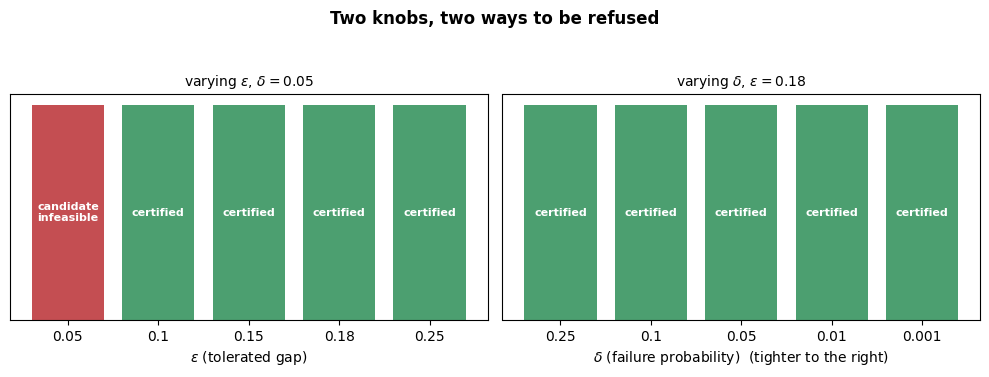

In [9]:
fig, (ax_e, ax_d) = plt.subplots(1, 2, figsize=(10, 3.8))

for ax, rows, xs, xlabel, title in (
    (
        ax_e,
        eps_rows,
        EPSILONS,
        r"$\epsilon$ (tolerated gap)",
        r"varying $\epsilon$, $\delta=0.05$",
    ),
    (
        ax_d,
        delta_rows,
        DELTAS,
        r"$\delta$ (failure probability)",
        r"varying $\delta$, $\epsilon=0.18$",
    ),
):
    colors = ["#4C9F70" if ok else "#C44E52" for _, ok, _ in rows]
    ax.bar(range(len(xs)), [1] * len(xs), color=colors)
    ax.set_xticks(range(len(xs)))
    ax.set_xticklabels([str(x) for x in xs])
    ax.set_yticks([])
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=10)
    for i, (_, ok, diag) in enumerate(rows):
        ax.text(
            i,
            0.5,
            "certified" if ok else diag.failure_mode.replace("_", "\n"),
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
        )

ax_d.set_xlabel(ax_d.get_xlabel() + "  (tighter to the right)")
fig.suptitle("Two knobs, two ways to be refused", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])

## What to take away

Refusal is the design, not a failure of it. A Seldonian algorithm returns a
model only when it can demonstrate the constraint holds; the alternative is
returning one whose fairness is merely hoped for.

When it refuses, `failure_mode` tells you which lever to reach for — relax the
definition, or gather more evidence. Those are different problems, and a bare
"No Solution Found" hides which one you have.
